<a href="https://colab.research.google.com/github/MuhammadQasimTanveer/HerdOrbit-ML/blob/main/image_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)

In [34]:
dataset_path = Path("/content/drive/MyDrive/HerdOrbit_Disease")

for folder in dataset_path.iterdir():
    if folder.is_dir():
        print(folder.name)

warts
ringworms
others
healthy
lumpy
foot-and-mouth


In [ ]:
for folder in dataset_path.iterdir():
    if folder.is_dir():
        count = len(list(folder.iterdir()))
        print(folder.name, ":", count)

In [ ]:
from pathlib import Path
split_path = Path("/content/drive/MyDrive/HerdOrbit_Disease_Split")
print(split_path)

In [ ]:
import random
import shutil

random.seed(42)
split_path = Path("/content/drive/MyDrive/HerdOrbit_Disease_Split")

for folder in dataset_path.iterdir():
    if folder.is_dir():

        images = list(folder.iterdir())
        random.shuffle(images)

        train = int(len(images) * 0.8)
        val = int(len(images) * 0.9)

        for name, files in { "train": images[:train],"val": images[train:val],"test": images[val:]}.items():
            new_folder = split_path / name / folder.name
            new_folder.mkdir(parents=True, exist_ok=True)

            for image in files:
                shutil.copy(image, new_folder / image.name)

print("Dataset split completed.")

In [ ]:
for split in ["train", "val", "test"]:
    print("\n", split.upper())

    for folder in (split_path / split).iterdir():
        if folder.is_dir():
            print(folder.name, ":", len(list(folder.iterdir())))

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("B0 preprocessing ready.")
print("Preprocessing and augmentation ready.")

In [40]:
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import torch
import numpy as np

# Load datasets
train_dataset = datasets.ImageFolder(split_path / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(split_path / "val", transform=val_test_transform)
test_dataset = datasets.ImageFolder(split_path / "test", transform=val_test_transform)

# Get training labels and class counts
targets = [label for _, label in train_dataset.samples]
class_counts = Counter(targets)
num_classes = len(train_dataset.classes)

# Give higher sampling probability to smaller classes
sample_weights = [1.0 / class_counts[label] for label in targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Calculate moderate class weights
counts = np.array([class_counts[i] for i in range(num_classes)])
raw_weights = 1.0 / counts
class_weights = raw_weights / raw_weights.sum() * num_classes

# Reduce the strength of the weights
class_weights = np.sqrt(class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# Create DataLoaders
train_loader = DataLoader(train_dataset,batch_size=32,sampler=sampler)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

print("Classes:", train_dataset.classes)
print("Class counts:", dict(class_counts))
print("Class weights:", class_weights)

Classes: ['foot-and-mouth', 'healthy', 'lumpy', 'others', 'ringworms', 'warts']
Class counts: {0: 596, 1: 564, 2: 564, 3: 564, 4: 52, 5: 59}
Class weights: tensor([0.4829, 0.4964, 0.4964, 0.4964, 1.6347, 1.5347])


In [ ]:
# Load pretrained EfficientNet-B0
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Freeze pretrained layers
for p in model.parameters():
    p.requires_grad = False

# Replace classifier for 6 disease classes
num_classes = len(train_dataset.classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Enable classifier training
for p in model.classifier.parameters():
    p.requires_grad = True

# Move model to GPU
model = model.to(device)

print("EfficientNet-B0 ready.")
print("Classes:", num_classes)

In [ ]:
import torch.optim as optim

# Freeze the pretrained backbone, Train only the classifier
for p in model.parameters():
    p.requires_grad = False

for p in model.classifier.parameters():
    p.requires_grad = True

# Use class weights for imbalanced classes
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimize classifier parameters
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("Classifier training ready.")

In [ ]:
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    # Training
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_acc = train_correct / len(train_dataset)
    val_acc = val_correct / len(val_dataset)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

                precision    recall  f1-score   support

foot-and-mouth     0.9661    0.7600    0.8507        75
       healthy     0.9091    0.8571    0.8824        70
         lumpy     0.8841    0.8714    0.8777        70
        others     0.9459    1.0000    0.9722        70
     ringworms     0.1765    0.4286    0.2500         7
         warts     0.4286    0.8571    0.5714         7

      accuracy                         0.8595       299
     macro avg     0.7184    0.7957    0.7341       299
  weighted avg     0.8978    0.8595    0.8723       299



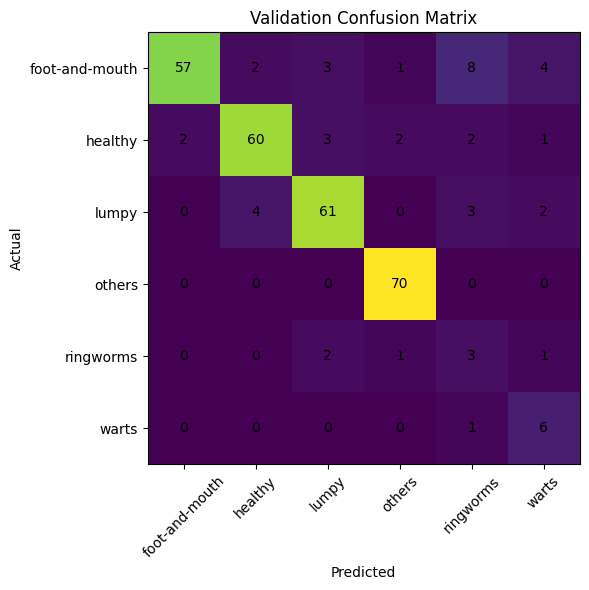

In [44]:
# Generate validation predictions
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes,
    digits=4
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(train_dataset.classes)), train_dataset.classes, rotation=45)
plt.yticks(range(len(train_dataset.classes)), train_dataset.classes)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
# Unfreeze last 2 feature blocks
for p in model.features[-2:].parameters():
    p.requires_grad = True

# Keep classifier trainable
for p in model.classifier.parameters():
    p.requires_grad = True

# Use a lower learning rate for fine-tuning
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

epochs = 10
fine_tune_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_acc = train_correct / len(train_dataset)
    val_acc = val_correct / len(val_dataset)

    fine_tune_history["train_loss"].append(train_loss)
    fine_tune_history["train_acc"].append(train_acc)
    fine_tune_history["val_loss"].append(val_loss)
    fine_tune_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

                precision    recall  f1-score   support

foot-and-mouth     0.9583    0.9200    0.9388        75
       healthy     0.9286    0.9286    0.9286        70
         lumpy     0.9394    0.8857    0.9118        70
        others     0.9333    1.0000    0.9655        70
     ringworms     0.5000    0.4286    0.4615         7
         warts     0.6000    0.8571    0.7059         7

      accuracy                         0.9197       299
     macro avg     0.8099    0.8367    0.8187       299
  weighted avg     0.9220    0.9197    0.9197       299



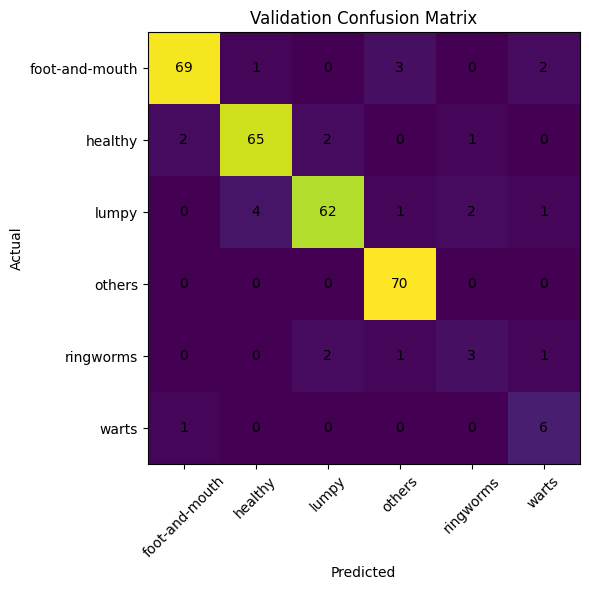

In [46]:
# Generate validation predictions
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes,
    digits=4
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(train_dataset.classes)), train_dataset.classes, rotation=45)
plt.yticks(range(len(train_dataset.classes)), train_dataset.classes)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
import os

model_dir = "/content/drive/MyDrive/HerdOrbit_Models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "model_b0.pth")
torch.save(model.state_dict(), model_path)

print("B3 model saved at:", model_path)

                precision    recall  f1-score   support

foot-and-mouth     0.9857    0.9200    0.9517        75
       healthy     0.8068    1.0000    0.8931        71
         lumpy     0.9655    0.7887    0.8682        71
        others     0.9861    1.0000    0.9930        71
     ringworms     0.8000    0.5714    0.6667         7
         warts     0.7000    0.8750    0.7778         8

      accuracy                         0.9175       303
     macro avg     0.8740    0.8592    0.8584       303
  weighted avg     0.9273    0.9175    0.9169       303



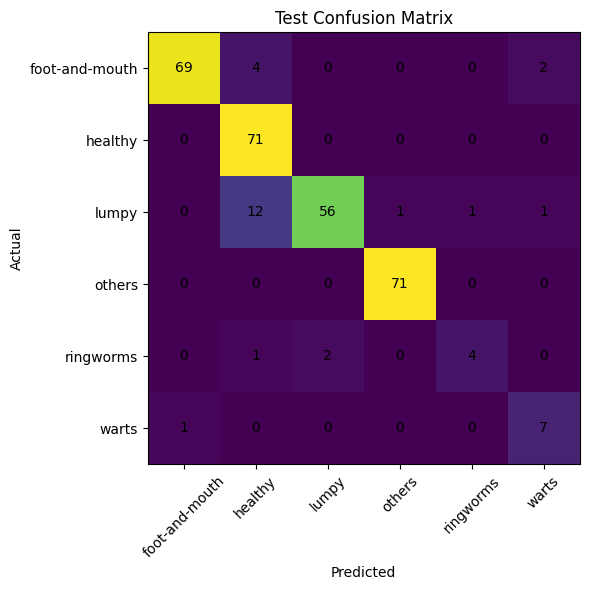

In [48]:
# Evaluate model on the test set
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes,
    digits=4
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(train_dataset.classes)), train_dataset.classes, rotation=45)
plt.yticks(range(len(train_dataset.classes)), train_dataset.classes)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()